# Econometrics: Simple Linear Regression (OLS)

ใช้หา "ความสัมพันธ์" ระหว่างตัวแปร ว่าตัวแปรหนึ่ง (X) ส่งผลกระทบต่ออีกตัวแปรหนึ่ง (Y) อย่างไรและมากน้อยแค่ไหน

สมการที่คลาสสิกที่สุดคือ Simple Linear Regression (สมการเส้นตรง):$$Y = \alpha + \beta X + \epsilon$$ 
$Y$ (Dependent Variable): ผลตอบแทนของหุ้นที่เราสนใจ (เช่น NVDA) 

$X$ (Independent Variable): ตัวแปรต้นเหตุ (เช่น ผลตอบแทนตลาด S&P500)

$\alpha$ (Alpha): จุดตัดแกน Y $\rightarrow$ ในทางการเงินคือ "ผลตอบแทนส่วนเกิน" ที่ผู้จัดการกองทุนทำได้โดยไม่เกี่ยวกับตลาด (นี่คือสิ่งที่ Quant ทุกคนตามหา!)

$\beta$ (Beta): ความชันของกราฟ $\rightarrow$ ความไวของหุ้นเทียบกับตลาด (ตัวเดียวกับที่เราเรียนใน CAPM แต่คราวนี้เราจะคำนวณมันออกมาจากข้อมูลจริง)

$\epsilon$ (Error Term): ส่วนที่อธิบายไม่ได้ (Noise หรือความเสี่ยงเฉพาะตัว)

สมมติรัน Regression หุ้น Tesla (TSLA) เทียบกับ S&P500 (SPY) โดยกำหนดให้ Error Term = 0 ก็จะได้สมการออกมาว่า:$$Return_{TSLA} = 0.05 + 1.5(Return_{SPY})$$ 

โจทย์: ให้หาค่า Alpha และ Beta ของหุ้น NVDA เมื่อเทียบกับตลาด SPY ว่าจริงๆ แล้ว NVDA ที่ขึ้นแรงๆ เป็นเพราะตลาดพาไป หรือเพราะมันเก่งโดยตัวมันเอง (ไม่ตามตลาด)

In [1]:
# 1. Import Library สำหรับสถิติ
import statsmodels.api as sm
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# ดึงข้อมูลราคาปิด (Adj Close) ของทุกตัว
tickers = ['NVDA', 'SPY']
data = yf.download(tickers, start="2020-01-01", end="2023-12-31",auto_adjust=False)['Adj Close']
returns = data.pct_change().dropna()

# 2. กำหนดตัวแปร X (ตัวอธิบาย) และ Y (ตัวตาม)
X = returns['SPY']  # ตลาด (Market)
Y = returns['NVDA'] # หุ้นรายตัว (Stock)

[*********************100%***********************]  2 of 2 completed


In [3]:
# 3. สำคัญ! ต้องเพิ่มค่าคงที่ (Intercept/Alpha) เข้าไปในสมการ
# ถ้าไม่ทำขั้นตอนนี้ statsmodels จะบังคับให้เส้นกราฟตัดที่จุด 0,0 ซึ่งผิดหลักการเงิน
X_with_constant = sm.add_constant(X)

In [4]:
# 4. สร้างโมเดล OLS (Ordinary Least Squares) และประมวลผล
model = sm.OLS(Y, X_with_constant)
results = model.fit()

In [5]:
# 5. แสดงผลลัพธ์ทางสถิติแบบละเอียด
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     1061.
Date:                Mon, 29 Dec 2025   Prob (F-statistic):          2.60e-159
Time:                        22:44:50   Log-Likelihood:                 2330.6
No. Observations:                1005   AIC:                            -4657.
Df Residuals:                    1003   BIC:                            -4647.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0018      0.001      2.328      0.0

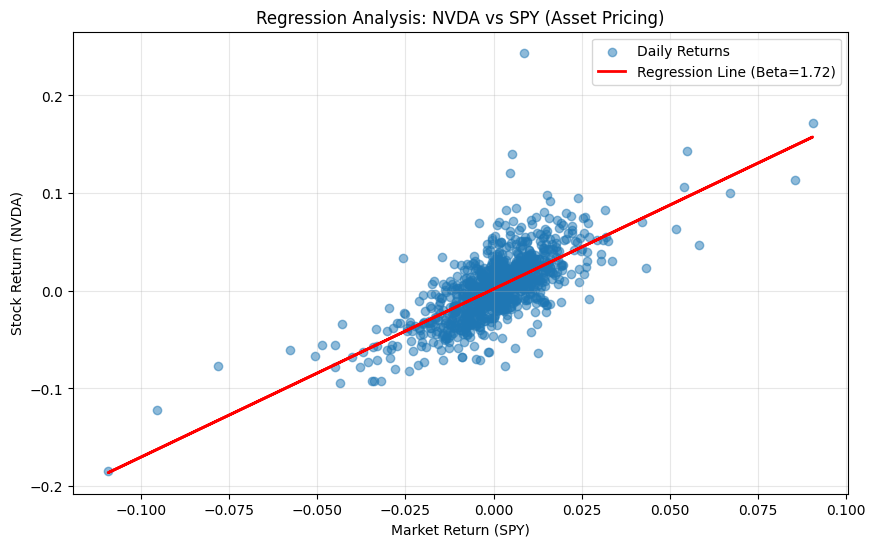

In [6]:
# --- Visualization (Scatter Plot & Regression Line) ---
plt.figure(figsize=(10, 6))

# จุด Scatter (ข้อมูลจริง)
plt.scatter(X, Y, alpha=0.5, label='Daily Returns')

# เส้น Regression (เส้นที่ AI สร้างขึ้น)
# สมการ: Y = alpha + beta * X
y_pred = results.params['const'] + results.params['SPY'] * X
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line (Beta={results.params["SPY"]:.2f})')

plt.title('Regression Analysis: NVDA vs SPY (Asset Pricing)')
plt.xlabel('Market Return (SPY)')
plt.ylabel('Stock Return (NVDA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# สรุปค่าสำคัญ
alpha = results.params['const']
beta = results.params['SPY']
r_squared = results.rsquared

print(f"\n--- 📊 Econometrics Report ---")
print(f"Alpha (ความเก่งเฉพาะตัว): {alpha:.5f} (ถ้า > 0 แปลว่าชนะตลาด)")
print(f"Beta (ความเสี่ยงเทียบตลาด): {beta:.2f} (ถ้า > 1 แปลว่าซิ่งกว่าตลาด)")
print(f"R-squared (ความแม่นยำโมเดล): {r_squared:.2f} (ตลาดอธิบายหุ้นตัวนี้ได้กี่ %)")


--- 📊 Econometrics Report ---
Alpha (ความเก่งเฉพาะตัว): 0.00175 (ถ้า > 0 แปลว่าชนะตลาด)
Beta (ความเสี่ยงเทียบตลาด): 1.72 (ถ้า > 1 แปลว่าซิ่งกว่าตลาด)
R-squared (ความแม่นยำโมเดล): 0.51 (ตลาดอธิบายหุ้นตัวนี้ได้กี่ %)


# Econometrics: Time Series Analysis (ACF/PACF)
Regression มีจุดอ่อนร้ายแรงข้อหนึ่ง คือ "มันไม่สนใจลำดับเวลา" 
แต่ความเป็นจริงการเงิน "เมื่อวาน" ส่งผลต่อ "วันนี้" เสมอ เลยจำเป็นต้องใช้ Time Series Analysis เข้ามาช่วย

Time Series คือการวิเคราะห์ข้อมูลที่เรียงต่อกันตามเวลา เพื่อหา Pattern ที่ซ่อนอยู่:

1. Trend: แนวโน้มระยะยาว (ขึ้น/ลง)

2. Seasonality: รูปแบบที่เกิดซ้ำๆ (เช่น ยอดขายไอติมสูงหน้าร้อน, หุ้นตกเดือนพฤษภา)

3. Autocorrelation (ACF): ความสัมพันธ์ของข้อมูลกับตัวมันเองในอดีต (เช่น ถ้าราคาหุ้นขึ้นเมื่อวาน วันนี้มีโอกาสขึ้นต่อไหม?)

วิเคราะห์หุ้น NVDA ในอดีต ด้วยฟังก์ชัน ACF (AutoCorrelation Function) เพื่อดูว่าราคาวันนี้ สัมพันธ์กับราคาเมื่อวานแค่ไหน

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [9]:
# 1. เตรียมข้อมูล

df = yf.download('NVDA', start="2020-01-01", end="2023-12-31", auto_adjust=False)
df['Daily_Return'] = df['Adj Close'].pct_change()

# เราจะเปรียบเทียบ 2 แบบ: "ราคา (Price)" vs "ผลตอบแทน (Return)"
price_data = df['Adj Close']
return_data = df['Daily_Return'].dropna()

[*********************100%***********************]  1 of 1 completed


In [10]:
# 2. Visualization (ACF Plot)
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

Text(0.5, 1.0, 'Autocorrelation of NVDA Price (Non-Stationary)')

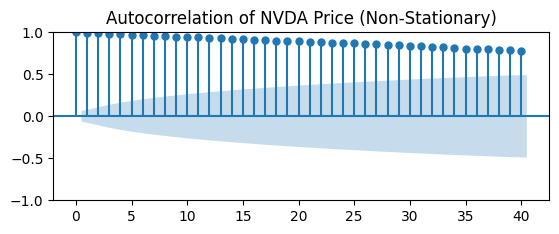

In [11]:
# กราฟที่ 1: ACF ของ "ราคา" (Price)
ax1 = plt.subplot(2, 1, 1)
plot_acf(price_data, lags=40, ax=ax1)
ax1.set_title('Autocorrelation of NVDA Price (Non-Stationary)')
# สังเกต: กราฟจะค่อยๆ ลดลงช้าๆ (แปลว่าจำอดีตแม่นมาก = ไม่นิ่ง)

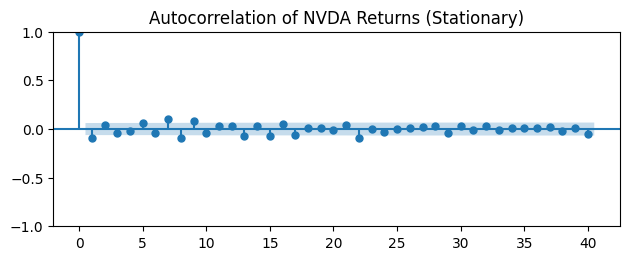

In [12]:
# กราฟที่ 2: ACF ของ "ผลตอบแทน" (Return)
ax2 = plt.subplot(2, 1, 2)
plot_acf(return_data, lags=40, ax=ax2)
ax2.set_title('Autocorrelation of NVDA Returns (Stationary)')
# สังเกต: กราฟจะตัดวูบลงทันที (แปลว่า Random Walk = นิ่งกว่า)

plt.tight_layout()
plt.show()

In [13]:
# --- Augmented Dickey-Fuller Test (ADF) ---
# นี่คือการทดสอบทางสถิติเพื่อยืนยันว่าข้อมูล "นิ่ง" (Stationary) หรือยัง?
from statsmodels.tsa.stattools import adfuller

print("\n--- 🧪 Statistical Test for Stationarity (ADF Test) ---")

def adf_test(series, name):
    result = adfuller(series)
    print(f"Testing {name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("✅ ผลลัพธ์: ข้อมูลนี้นิ่งแล้ว (Stationary) -> พร้อมเข้าโมเดล")
    else:
        print("❌ ผลลัพธ์: ข้อมูลนี้ยังไม่นิ่ง (Non-Stationary) -> ห้ามเอาไปรัน Regression ตรงๆ")
    print("-" * 30)

adf_test(price_data, "NVDA Price")
adf_test(return_data, "NVDA Returns")


--- 🧪 Statistical Test for Stationarity (ADF Test) ---
Testing NVDA Price:
ADF Statistic: 0.0967
P-value: 0.9658
❌ ผลลัพธ์: ข้อมูลนี้ยังไม่นิ่ง (Non-Stationary) -> ห้ามเอาไปรัน Regression ตรงๆ
------------------------------


Testing NVDA Returns:
ADF Statistic: -9.8159
P-value: 0.0000
✅ ผลลัพธ์: ข้อมูลนี้นิ่งแล้ว (Stationary) -> พร้อมเข้าโมเดล
------------------------------


# Forecasting with ARIMA (AutoRegressive Integrated Moving Average)

ARIMA ประกอบด้วย 3 ส่วนผสมหลัก $(p, d, q)$ ที่คุณต้องจูนค่า:

1. AR (AutoRegressive - p): 
- "อดีตกำหนดอนาคต"สมมติฐาน: ถ้าเมื่อวานหุ้นขึ้น วันนี้ก็น่าจะขึ้นต่อ (Momentum) หรือถ้าเมื่อวานขึ้นเยอะเกินไป วันนี้อาจจะลง (Mean Reversion)
- สมการ: $Y_t = \alpha + \beta_1 Y_{t-1} + ...$

2. I (Integrated - d): 
- "การทำให้ข้อมูลนิ่ง"คือจำนวนครั้งที่ต้องลบข้อมูล (Differencing) เพื่อให้นิ่ง
- สามารถแปลงเป็น Return แล้ว ซึ่งก็นับเป็น $d=0$ หรือ $d=1$ แล้วแต่กรณี

3. MA (Moving Average - q): 
- "เรียนรู้จากความผิดพลาด"สมมติฐาน: ถ้าเมื่อวานโมเดลทายผิดไปเยอะ (Error Term สูง) วันนี้ก็จะเอาค่าความผิดพลาดนั้นมาแก้ตัวในสมการใหม่
- สมการ: $Y_t = \epsilon_t + \theta_1 \epsilon_{t-1} + ...$


$เป้าหมาย: หาค่า $(p, d, q)$ ที่ดีที่สุด เพื่อสร้างเส้นกราฟพยากรณ์ไปข้างหน้า

In [22]:
# --- Econometrics: ARIMA Forecasting ---
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

In [23]:
# 1. เตรียมข้อมูล (ใช้ข้อมูล Return ที่นิ่งแล้ว)
# แบ่งข้อมูลเป็น Train (อดีต) / Test (อนาคตจำลอง) เพื่อวัดผล
train_size = int(len(return_data) * 0.9)
train, test = return_data[0:train_size], return_data[train_size:]

print(f"Training Data: {len(train)} วัน")
print(f"Testing Data: {len(test)} วัน")

Training Data: 904 วัน
Testing Data: 101 วัน


In [24]:
# 2. สร้างและเทรนโมเดล ARIMA
# order=(p,d,q) -> ลองใช้ (1, 0, 1) ไปก่อน
model = ARIMA(train, order=(2, 0, 2)) 
model_fit = model.fit()

f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

In [25]:
# 3. ดูผลลัพธ์ทางสถิติของโมเดล
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Daily_Return   No. Observations:                  904
Model:                 ARIMA(2, 0, 2)   Log Likelihood                1749.458
Date:                Mon, 29 Dec 2025   AIC                          -3486.916
Time:                        22:46:03   BIC                          -3458.075
Sample:                             0   HQIC                         -3475.901
                                - 904                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.001      2.611      0.009       0.001       0.005
ar.L1         -0.7165      0.893     -0.803      0.422      -2.466       1.033
ar.L2         -0.2843      0.472     -0.603      0.5

In [26]:
# 4. พยากรณ์ (Forecasting)
# ให้โมเดลลองทายผลในช่วง Test set
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index # ใส่ index วันที่ให้ตรงกัน

f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
f:\MyProject\BriefStreet\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


f:\MyProject\BriefStreet\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\MyProject\BriefStreet\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\MyProject\BriefStreet\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\MyProject\BriefStreet\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\MyProject\BriefStreet\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sa

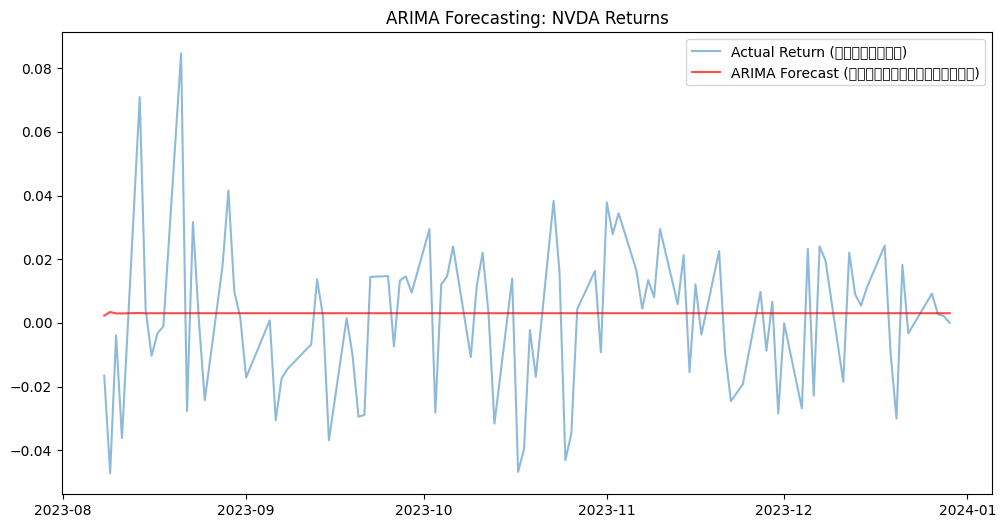

In [27]:
# 5. Visualization (กราฟเปรียบเทียบ)
plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual Return (ความจริง)', alpha=0.5)
plt.plot(forecast, label='ARIMA Forecast (สิ่งที่โมเดลทาย)', color='red', alpha=0.7)
plt.title('ARIMA Forecasting: NVDA Returns')
plt.legend()
plt.show()

In [28]:
# 6. วัดความแม่นยำ (RMSE)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"\n--- 🎯 Model Accuracy ---")
print(f"RMSE (ความคลาดเคลื่อนเฉลี่ย): {rmse:.4f}")
print(f"เทียบกับ SD ของข้อมูลจริง: {test.std():.4f}")
if rmse < test.std():
    print("✅ โมเดลมีความแม่นยำกว่าการเดาสุ่ม (นิดหน่อย)")
else:
    print("❌ โมเดลยังไม่แม่นยำ (การทำนายหุ้นรายวันยากมาก!)")


--- 🎯 Model Accuracy ---
RMSE (ความคลาดเคลื่อนเฉลี่ย): 0.0233
เทียบกับ SD ของข้อมูลจริง: 0.0234
✅ โมเดลมีความแม่นยำกว่าการเดาสุ่ม (นิดหน่อย)


# Volatility Modeling (GARCH)

GARCH (Generalized AutoRegressive Conditional Heteroskedasticity)

- Volatility Clustering (ความเสี่ยงมักจะกระจุกตัว):ช่วงไหนตลาดผันผวน มันก็จะผันผวนติดต่อกันหลายวัน (เช่น ช่วงโควิด) ช่วงไหนตลาดนิ่ง มันก็นิ่งยาว ๆ
- ARCH Effect: ความผันผวนของวันนี้ ($\sigma_t^2$) ขึ้นอยู่กับ "ความตกใจในอดีต" (Error term: $\epsilon_{t-1}^2$) และ "ความผันผวนในอดีต" ($\sigma_{t-1}^2$)

In [29]:
# !pip install arch 
from arch import arch_model

In [30]:
# 1. เตรียมข้อมูล (ใช้ Return ที่เป็น % จะคำนวณง่ายกว่า)
# คูณ 100 เพื่อแปลงเป็นหน่วย % (เช่น 0.02 -> 2.0) โมเดล GARCH จะทำงานได้เสถียรกว่า
returns_pct = return_data * 100

In [31]:
# 2. สร้างโมเดล GARCH(1,1)
# vol='Garch' : ระบุว่าจะทำ Volatility Model
# p=1, q=1 : ใช้ค่าความผันผวนเมื่อวาน 1 วัน และค่า error เมื่อวาน 1 วัน
garch_model = arch_model(returns_pct, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp='off') # disp='off' เพื่อปิด log การคำนวณยาวๆ

In [32]:
# 3. ดูผลลัพธ์
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:           Daily_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2610.59
Distribution:                  Normal   AIC:                           5229.19
Method:            Maximum Likelihood   BIC:                           5248.84
                                        No. Observations:                 1005
Date:                Mon, Dec 29 2025   Df Residuals:                     1004
Time:                        23:09:11   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.3190  9.711e-02      3.285  1.021e-03 [  0.129,  0.50

In [33]:
# 4. พยากรณ์ความเสี่ยง (Forecasting Volatility)
# horizon=5 : ทำนายความผันผวนล่วงหน้า 5 วัน
forecast_vol = garch_fit.forecast(horizon=5)
variance_forecast = forecast_vol.variance.iloc[-1] # ค่าความแปรปรวน (Variance) ล่าสุด
volatility_forecast = np.sqrt(variance_forecast)   # แปลงเป็น SD (Volatility)

print("\n--- 🌋 Volatility Forecast (Next 5 Days) ---")
print(volatility_forecast)


--- 🌋 Volatility Forecast (Next 5 Days) ---
h.1    2.394615
h.2    2.473701
h.3    2.545703
h.4    2.611485
h.5    2.671761
Name: 2023-12-29 00:00:00, dtype: float64


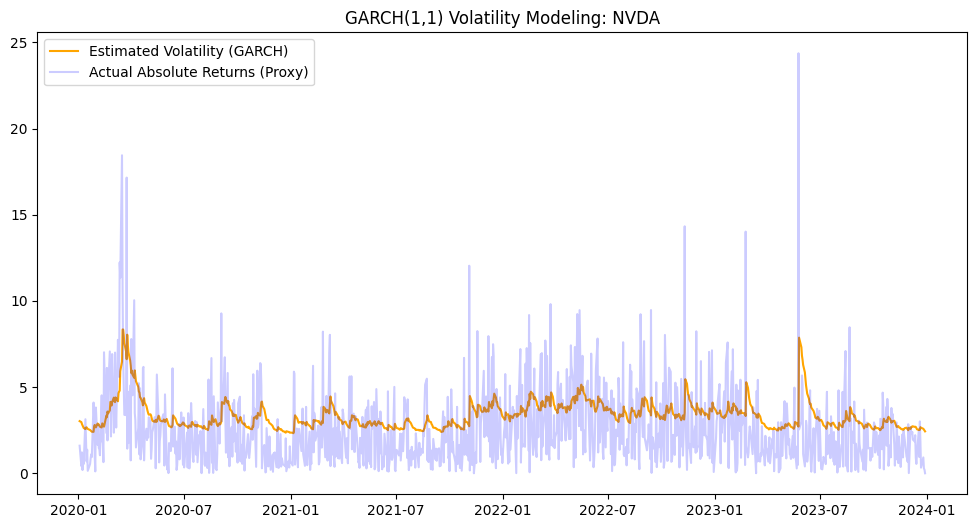

In [36]:
# 5. Visualization (กราฟความผันผวนที่แท้จริงเทียบกับที่โมเดลทาย)
plt.figure(figsize=(12, 6))
# conditional_volatility คือสิ่งที่โมเดลคำนวณได้จากข้อมูลในอดีต
plt.plot(garch_fit.conditional_volatility, color='orange', label='Estimated Volatility (GARCH)')
plt.plot(np.abs(returns_pct), color='blue', alpha=0.2, label='Actual Absolute Returns (Proxy)')
plt.title(f'GARCH(1,1) Volatility Modeling: NVDA')
plt.legend()
plt.show()